In [1]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
insurance_data = pd.read_csv("insurance.csv")

In [9]:
X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

# One Hot Encoding for region (NOT regions)
X = pd.get_dummies(X, columns=["region"], drop_first=False , dtype = int)       # dtype krne se sab  0 and 1 mee ho gye 

# Label Encoding
X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

MSE for alpha = 0.001 :  33596918.49260663
MSE for alpha = 0.1 :  33597180.375486486
MSE for alpha = 1 :  33605932.26390232
MSE for alpha = 2 :  33615034.16817719
MSE for alpha = 5 :  33641228.01264165
MSE for alpha = 10 :  33681318.78237888
MSE for alpha = 20 :  33764201.88887348
MSE for alpha = 30 :  33851777.379185945
MSE for alpha = 40 :  33904639.0554767
MSE for alpha = 50 :  33950393.34079369
MSE for alpha = 100 :  34215583.12377537


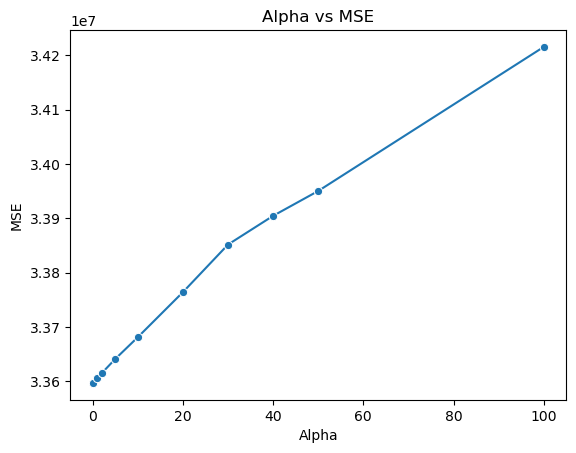

In [10]:

import seaborn as sns
import matplotlib.pyplot as plt


alphas = [0.001,0.1,1,2,5,10,20,30,40,50,100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)

    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for alpha = {a} : ", mse)

    mses.append(mse)

# Loop ke bahar plot likho
sns.lineplot(x=alphas, y=mses, marker="o")
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.title("Alpha vs MSE")
plt.show()

In [14]:
from sklearn.linear_model import LassoCV
a = [0.001,0.1,1,2,5,10,20 ,30,40,50,100]

lasso_cv_model = LassoCV(
    alphas = a,
    cv = 5,
    max_iter = 1000,
    random_state = 42
)

lasso_cv_model.fit(X_train , y_train)

print("Best Alpha : ",lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
print("mse=",mse)

    

Best Alpha :  100.0
mse= 34215583.12377537
